<a href="https://colab.research.google.com/github/shivansh2310/Finance-Stuff/blob/main/The_Climate_Extended_Risk_Model_(CERM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

In [17]:
np.random.seed(1234)

In [18]:
# Systematic risk factors: [Economic, Transition, Physical]
C = np.array([[1.0, -0.3, 0.1],   # Correlation matrix
              [-0.3, 1.0, 0.2],
              [0.1, 0.2, 1.0]])

In [19]:
# Groups (e.g., sectors/regions)
groups = {
    "Group1": {"factor_loadings": [0.6, 0.3, 0.1], "pd_base": 0.03},
    "Group2": {"factor_loadings": [0.4, 0.5, 0.2], "pd_base": 0.05}
}


In [20]:
# Toy portfolio: 100 loans
portfolio = pd.DataFrame({
    "LoanID": range(100),
    "Group": np.random.choice(["Group1", "Group2"], 100),
    "EAD": np.random.lognormal(mean=5, sigma=1, size=100)  # Exposure at Default
})


In [21]:
portfolio

,LoanID,Group,EAD
0,0,Group2,190.146000
1,1,Group2,60.512092
2,2,Group1,129.438410
3,3,Group2,151.152489
4,4,Group1,315.896296
...,...,...,...
95,95,Group2,497.892258
96,96,Group1,329.453565
97,97,Group1,101.513238
98,98,Group2,299.634148


In [22]:
# Recovery rate parameters (μ, σ)
recovery_params = {"μ": 0.4, "σ": 0.2}

In [23]:
def compute_asset_value(Z, factor_loadings):
    """Compute normalized asset value (Eq 9)"""
    systematic = np.dot(factor_loadings, Z)
    idiosyncratic = np.random.normal(0, 1)
    return systematic + np.sqrt(1 - np.dot(factor_loadings, factor_loadings)) * idiosyncratic

In [24]:
def conditional_pd(Z, group):
    """Compute conditional PD given systematic factors (Eq 28)"""
    loadings = groups[group]["factor_loadings"]
    z_threshold = norm.ppf(groups[group]["pd_base"])
    denominator = np.sqrt(1 - np.dot(loadings, loadings))
    return norm.cdf((z_threshold - np.dot(loadings, Z)) / denominator)

In [25]:
def recovery_rate(Z, group):
    """Compute stochastic recovery rate (Eq 10)"""
    loadings = groups[group]["factor_loadings"]
    systematic_part = np.dot(loadings, Z)
    return norm.cdf(recovery_params["μ"] + recovery_params["σ"] * systematic_part)

In [26]:
# Monte Carlo Simulation

n_simulations = 1000
losses = np.zeros(n_simulations)

for i in range(n_simulations):
    # Simulate systematic risk factors
    Z = multivariate_normal.rvs(mean=np.zeros(3), cov=C)

    total_loss = 0
    for _, loan in portfolio.iterrows():
        group = loan["Group"]

        # 1. Compute conditional PD
        pd = conditional_pd(Z, group)

        # 2. Check default
        if np.random.rand() < pd:
            # 3. Compute loss given default
            rr = recovery_rate(Z, group)
            total_loss += loan["EAD"] * (1 - rr)

    losses[i] = total_loss

In [27]:
# Risk Metrics

expected_loss = np.mean(losses)
var_99 = np.quantile(losses, 0.99)

print(f"Expected Loss: ${expected_loss:,.2f}")
print(f"99% VaR: ${var_99:,.2f}")

Expected Loss: $277.89
99% VaR: $2,708.40


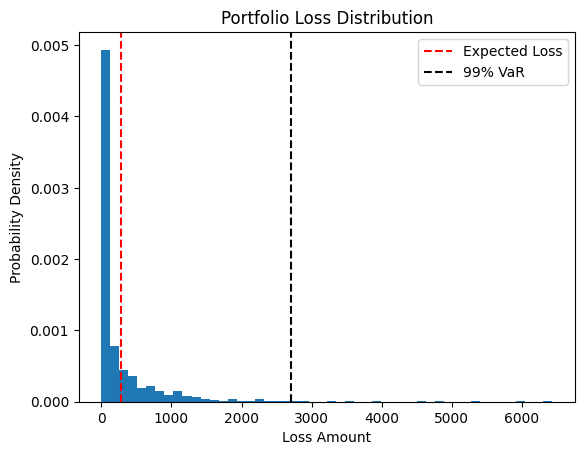

In [28]:
plt.hist(losses, bins=50, density=True)
plt.title("Portfolio Loss Distribution")
plt.xlabel("Loss Amount")
plt.ylabel("Probability Density")
plt.axvline(expected_loss, color='r', linestyle='--', label='Expected Loss')
plt.axvline(var_99, color='k', linestyle='--', label='99% VaR')
plt.legend()
plt.show()